Taking a example db and working on it

In [ ]:
import pandas as pd
import numpy as np
path=r"/content/sample_data/california_housing_train.csv"
df=pd.read_csv(path)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.isna().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
df.loc[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


**Exploratory Data Analysis**

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
df[['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']].describe()


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


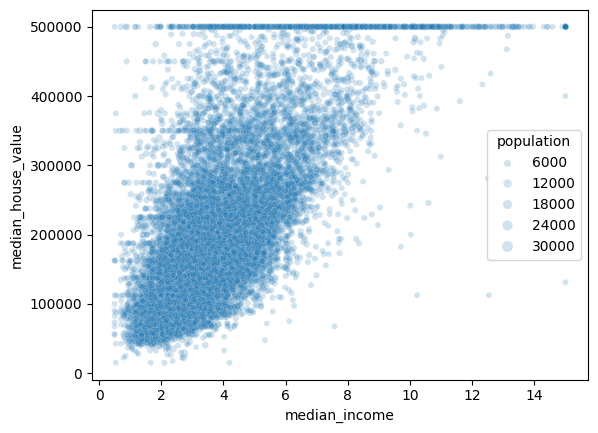

In [ ]:
sns.scatterplot(data=df,\
                x='median_income',
                y='median_house_value',
                size='population',
                alpha=.2)
plt.show()

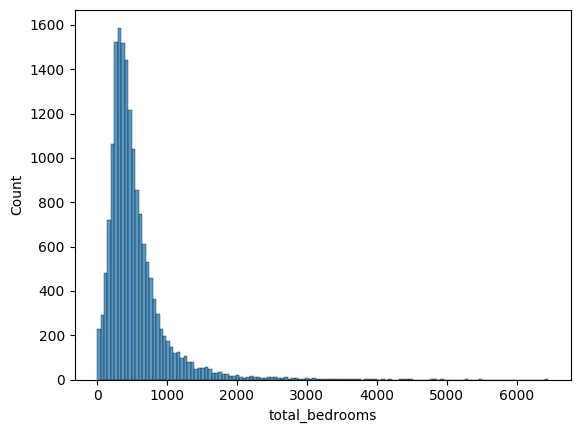

In [ ]:
sns.histplot(data=df,x='total_bedrooms',bins=130)
plt.show()


In [ ]:
bedroom_freq = (
    df.groupby("total_bedrooms")
      .agg(
          count=("total_bedrooms", "size"),
          avg_price=("median_house_value", "mean")
      )
)
bedroom_freq.head()

,count,avg_price
total_bedrooms,,
1.0,1,500001.000000
2.0,1,137500.000000
3.0,4,287500.000000
4.0,6,207500.166667
5.0,4,293750.000000


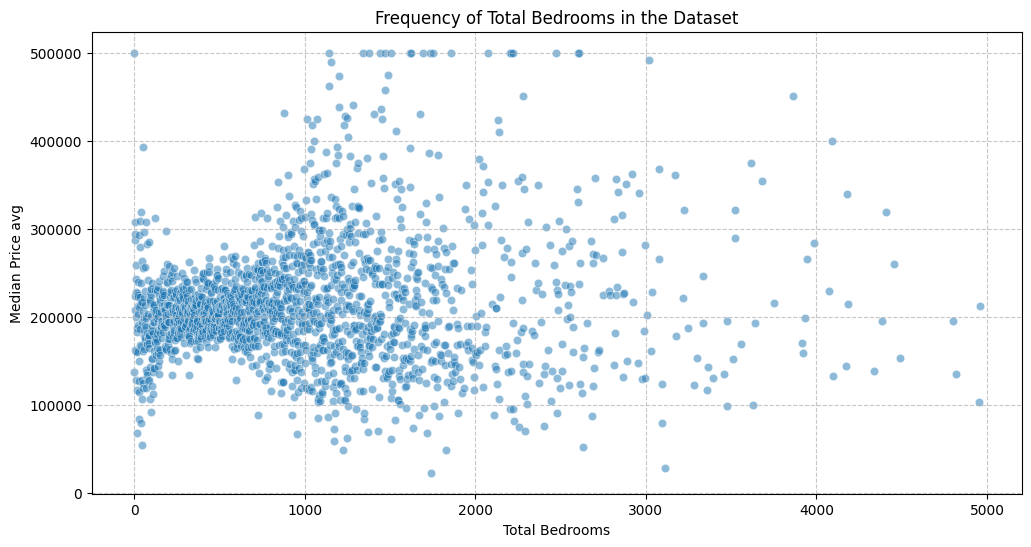

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=bedroom_freq.index, y='avg_price', data=bedroom_freq,alpha=.5)
plt.title('Frequency of Total Bedrooms in the Dataset')
plt.xlabel('Total Bedrooms')
plt.ylabel('Median Price avg')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Using boolean indexing to keep desired rows (more common and robust for filtering)
df = df[df['total_bedrooms'] <= 5000]

# Display the shape to confirm rows were dropped
df.reset_index(drop=True, inplace=True)
df.shape
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16992,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16993,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16994,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16995,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


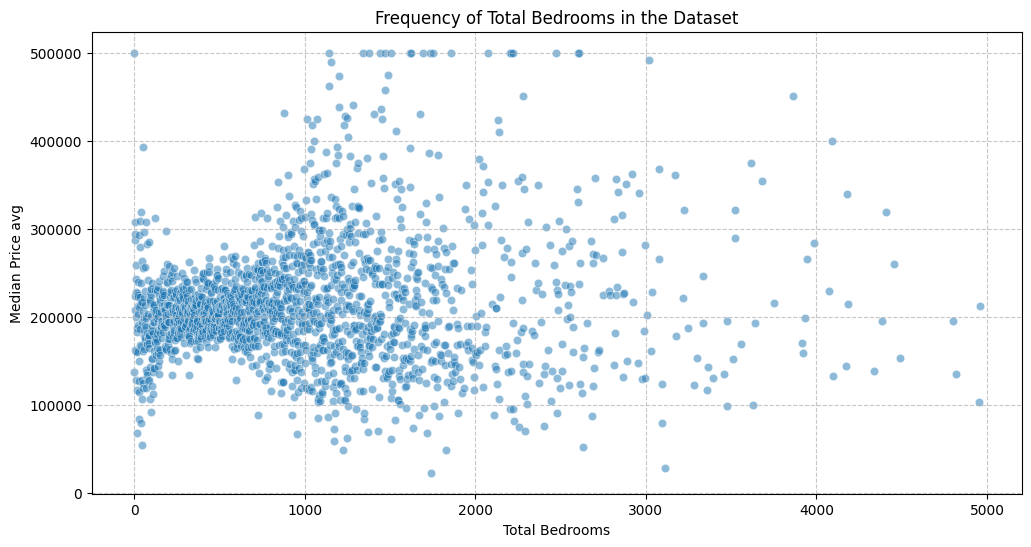

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=bedroom_freq.index, y='avg_price', data=bedroom_freq,alpha=.5)
plt.title('Frequency of Total Bedrooms in the Dataset')
plt.xlabel('Total Bedrooms')
plt.ylabel('Median Price avg')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
corr_matrix = df.corr(numeric_only=True)


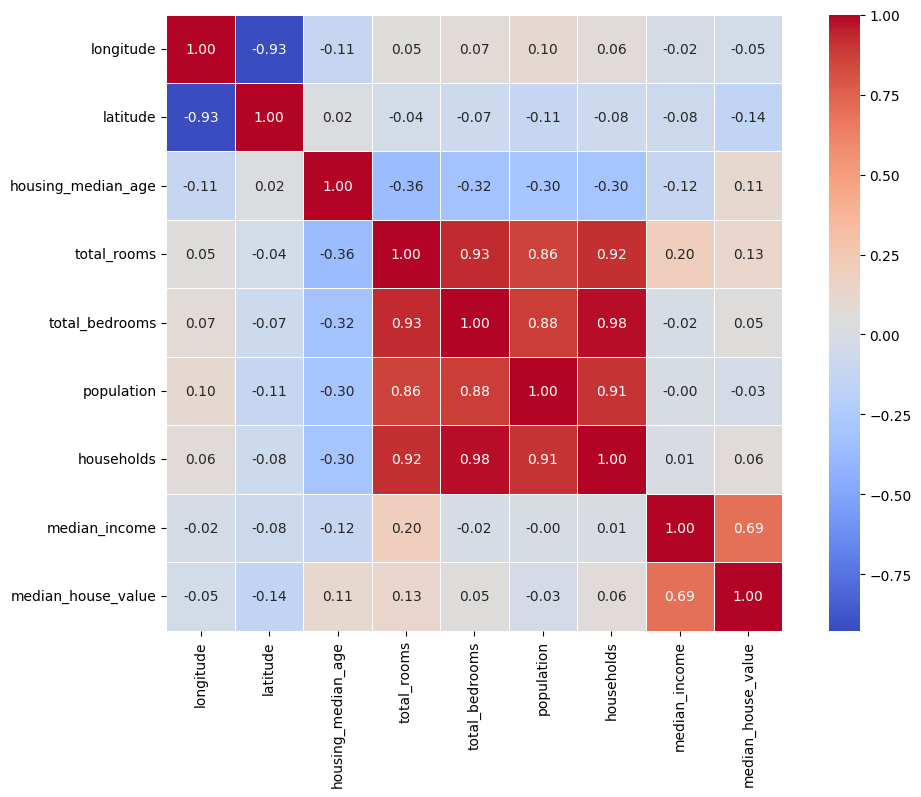

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.show()

In [ ]:
df['rooms_per_household']=df['total_rooms']/df['households']
df['bedrooms_per_room']=df['total_bedrooms']/df['total_rooms']
df['population_per_household']=df['population']/df['households']

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'],
      dtype='object')

In [ ]:
corr_matrix = df[['longitude', 'latitude', 'housing_median_age','median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household']].corr(numeric_only=True)

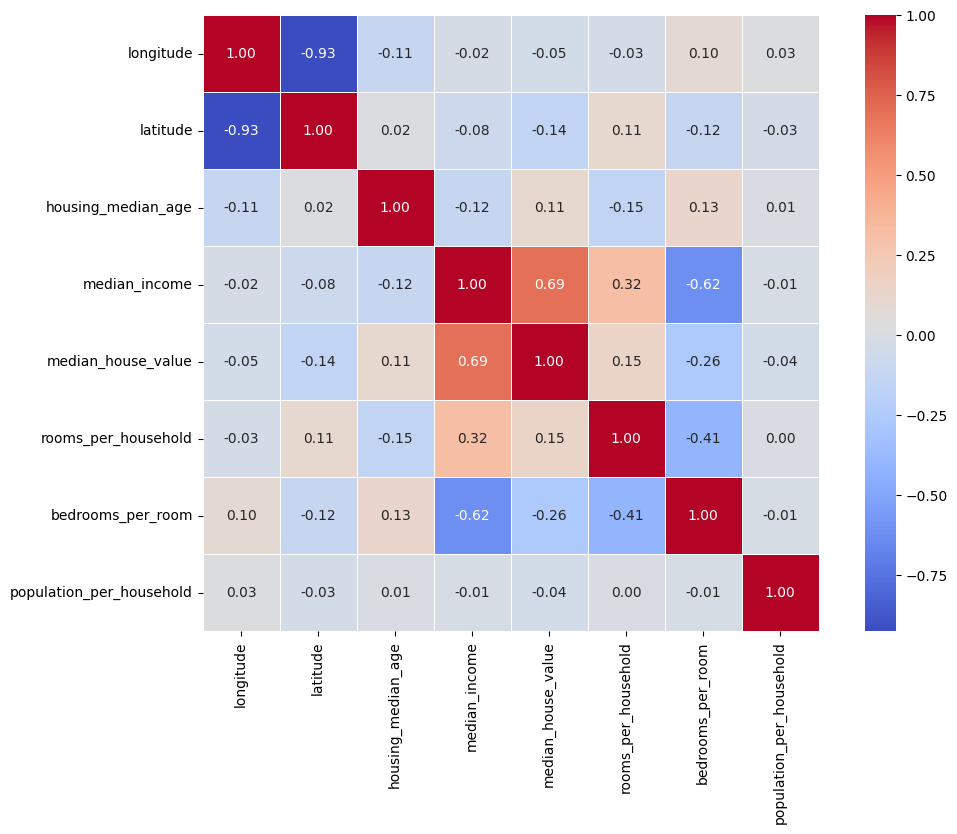

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.show()